# Explore here

In [119]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [120]:
df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [122]:
df.shape

(1599, 12)

In [123]:
df.duplicated().sum()

np.int64(240)

In [124]:
df['label'] = df['quality'].apply(lambda x: 0 if x < 6 else 1 if x > 6 else 2)
df['label'].head()

0    0
1    0
2    0
3    2
4    0
Name: label, dtype: int64

In [125]:
df['label'].value_counts()

label
0    744
2    638
1    217
Name: count, dtype: int64

In [126]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

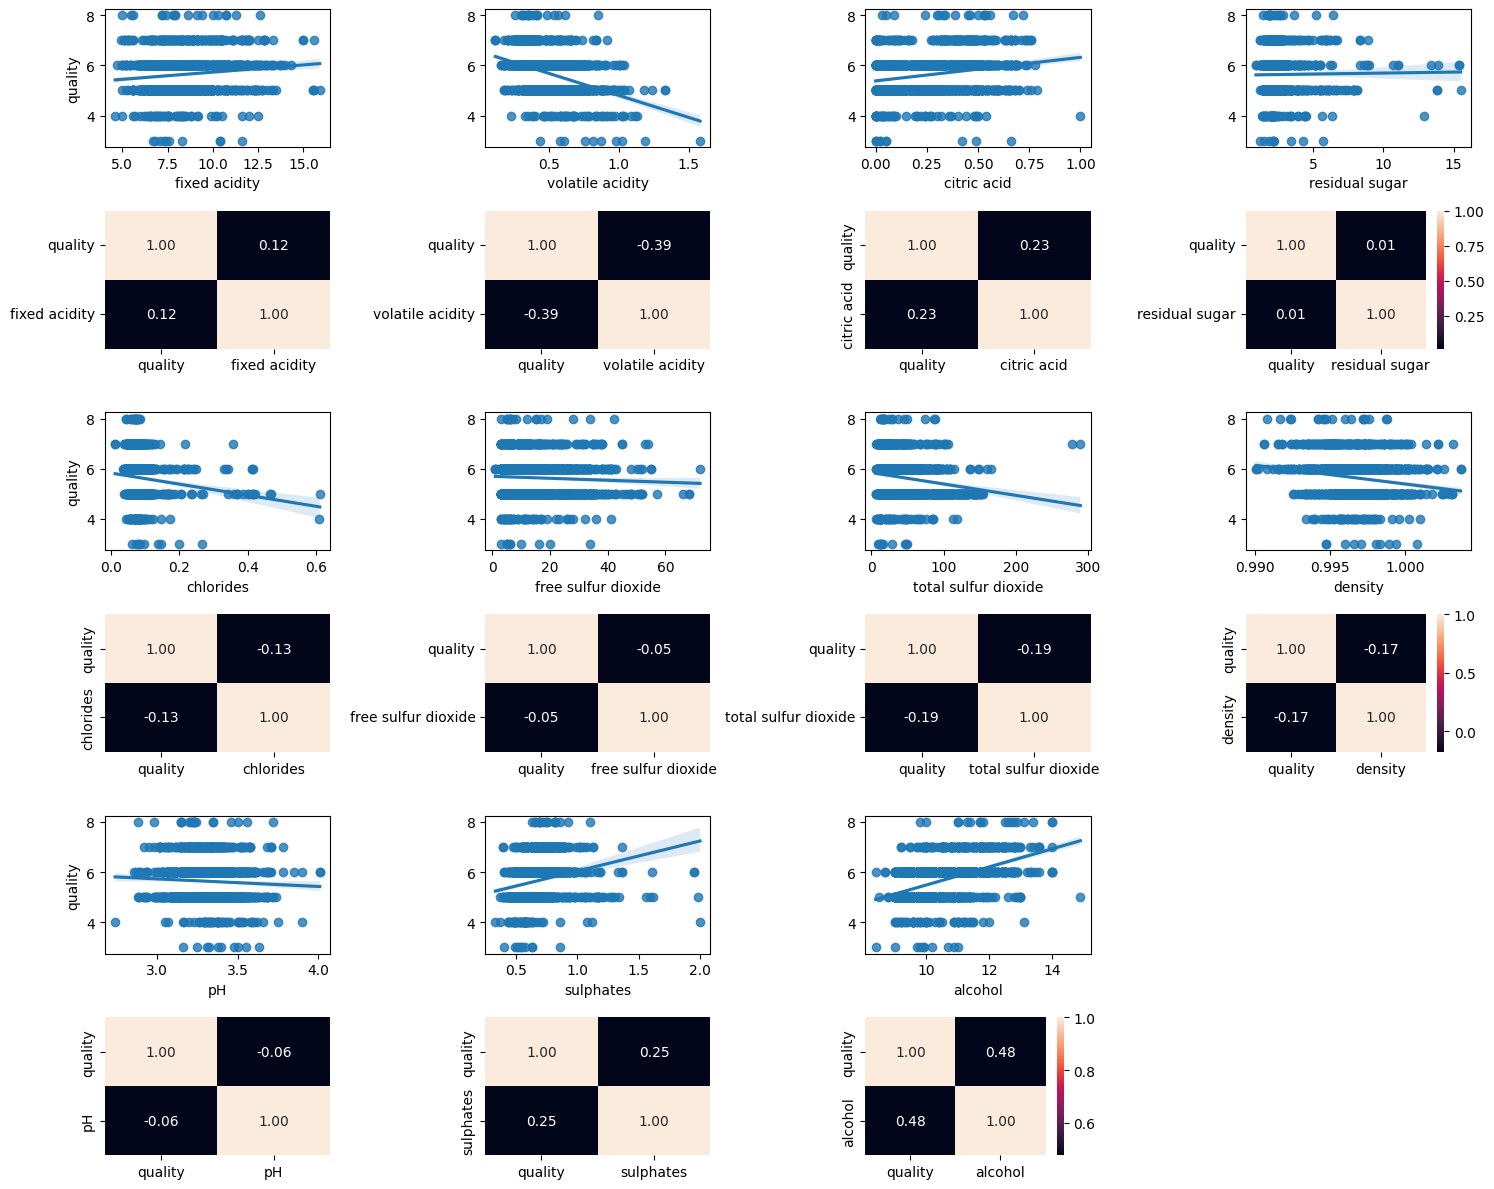

In [127]:
fig, axis = plt.subplots(6, 4, figsize = (15, 12))

sns.regplot(ax = axis[0, 0], data = df, x = "fixed acidity", y = "quality")
sns.heatmap(df[["quality", "fixed acidity"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "volatile acidity", y = "quality").set(ylabel = None)
sns.heatmap(df[["quality", "volatile acidity"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

sns.regplot(ax = axis[0, 2], data = df, x = "citric acid", y = "quality").set(ylabel = None)
sns.heatmap(df[["quality", "citric acid"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2], cbar = False)

sns.regplot(ax = axis[0, 3], data = df, x = "residual sugar", y = "quality").set(ylabel = None)
sns.heatmap(df[["quality", "residual sugar"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 3])

sns.regplot(ax = axis[2, 0], data = df, x = "chlorides", y = "quality")
sns.heatmap(df[["quality", "chlorides"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0], cbar = False)

sns.regplot(ax = axis[2, 1], data = df, x = "free sulfur dioxide", y = "quality").set(ylabel = None)
sns.heatmap(df[["quality", "free sulfur dioxide"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1], cbar = False)

sns.regplot(ax = axis[2, 2], data = df, x = "total sulfur dioxide", y = "quality").set(ylabel = None)
sns.heatmap(df[["quality", "total sulfur dioxide"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 2], cbar = False)

sns.regplot(ax = axis[2, 3], data = df, x = "density", y = "quality").set(ylabel = None)
sns.heatmap(df[["quality", "density"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 3])

sns.regplot(ax = axis[4, 0], data = df, x = "pH", y = "quality")
sns.heatmap(df[["quality", "pH"]].corr(), annot = True, fmt = ".2f", ax = axis[5, 0], cbar = False)

sns.regplot(ax = axis[4, 1], data = df, x = "sulphates", y = "quality").set(ylabel = None)
sns.heatmap(df[["quality", "sulphates"]].corr(), annot = True, fmt = ".2f", ax = axis[5, 1], cbar = False)

sns.regplot(ax = axis[4, 2], data = df, x = "alcohol", y = "quality").set(ylabel = None)
sns.heatmap(df[["quality", "alcohol"]].corr(), annot = True, fmt = ".2f", ax = axis[5, 2])

plt.delaxes(ax=axis[4,3])
plt.delaxes(ax=axis[5,3])

plt.tight_layout()
plt.show()

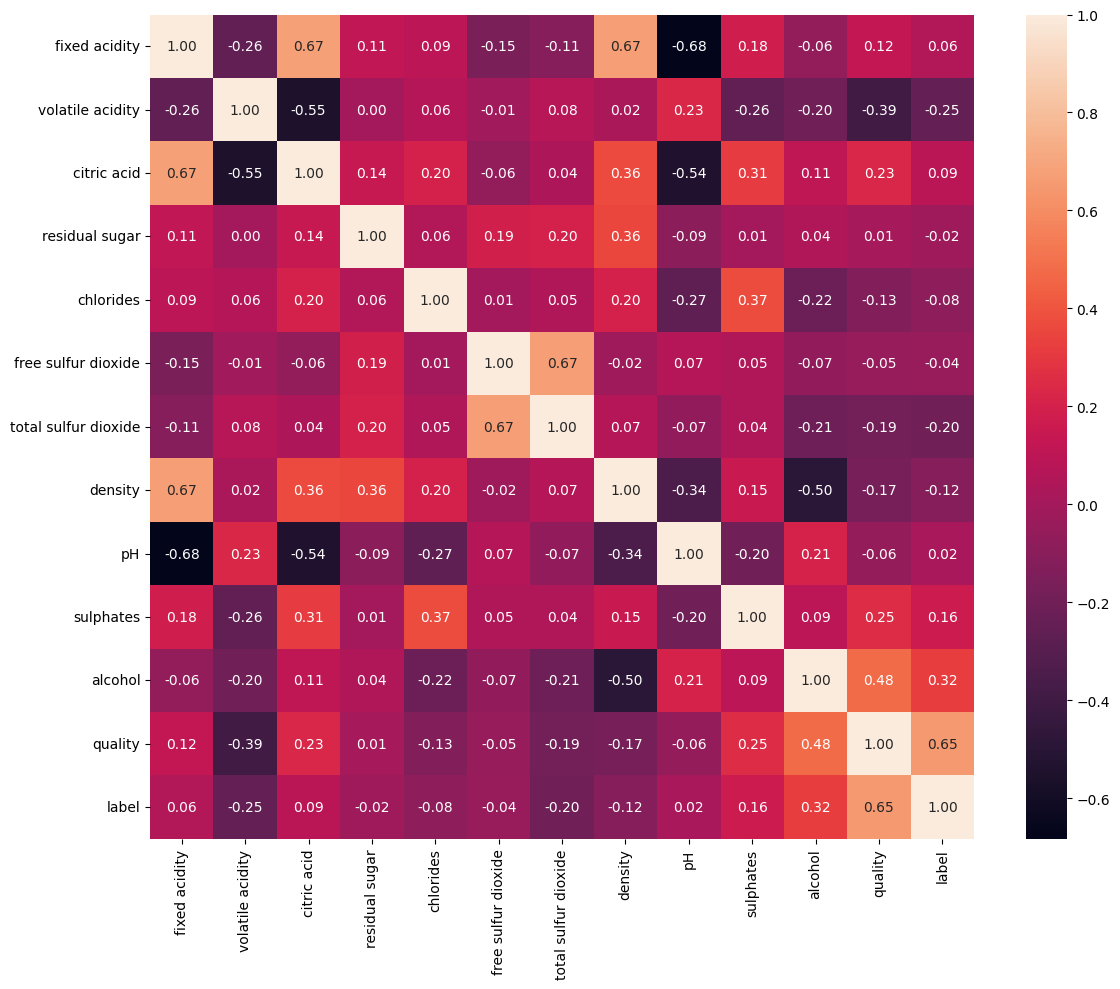

In [128]:
fig, axes = plt.subplots(figsize=(12, 10))

sns.heatmap(df.corr(), annot = True, fmt = ".2f")

plt.tight_layout()
plt.show()

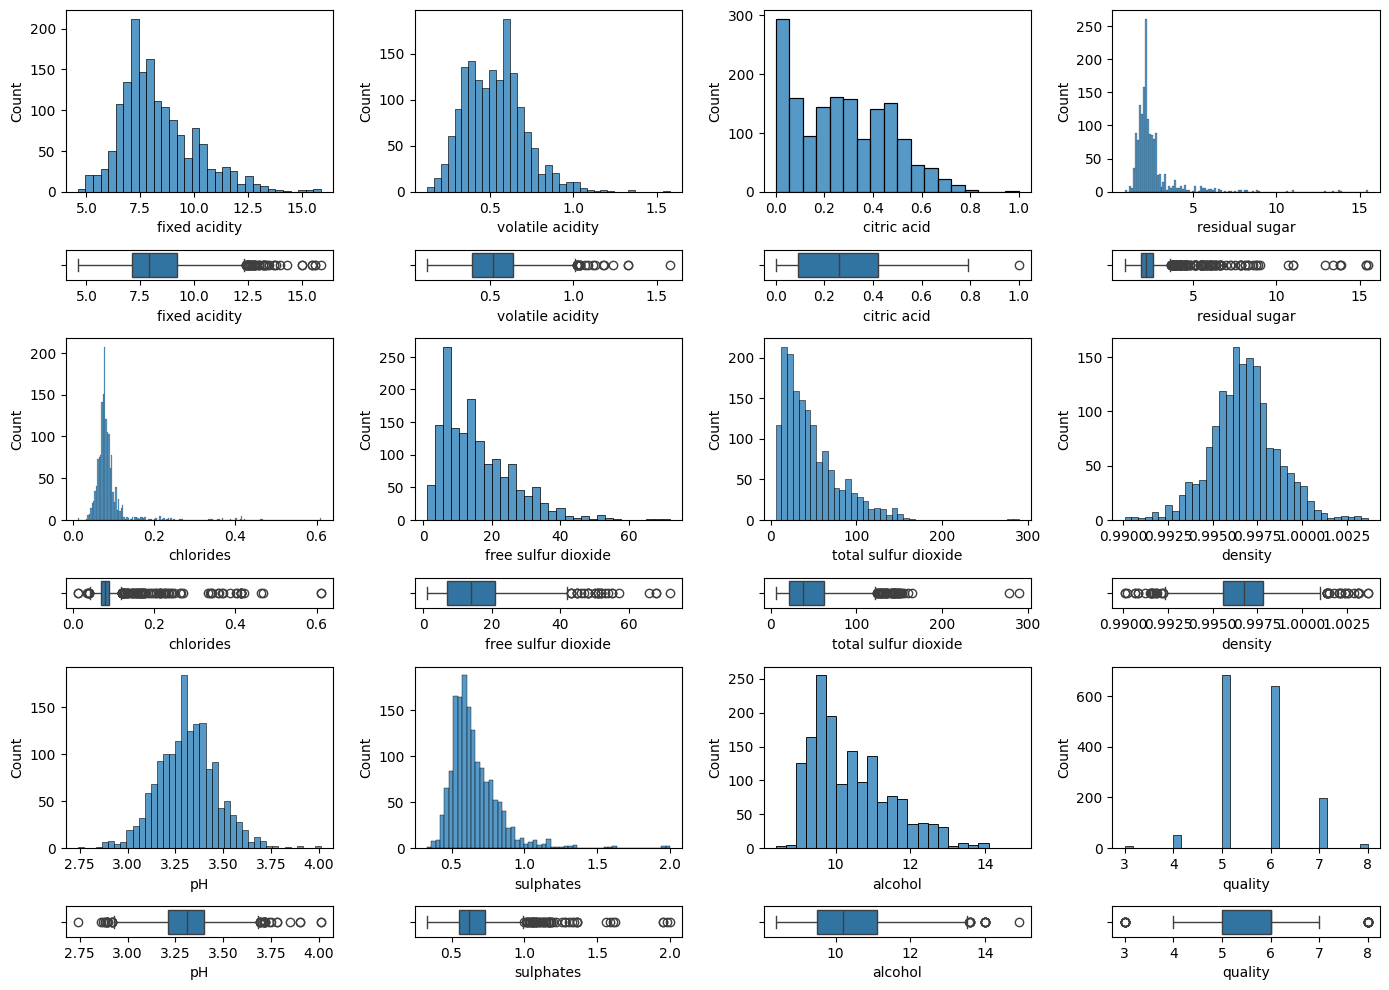

In [129]:
ig, axis = plt.subplots(6, 4, figsize=(14, 10), gridspec_kw = {"height_ratios": [6, 1, 6, 1, 6, 1]})

sns.histplot(ax = axis[0,0], data = df, x = "fixed acidity")
sns.boxplot(ax = axis[1,0], data = df, x = "fixed acidity")
sns.histplot(ax = axis[0,1], data = df, x = "volatile acidity")
sns.boxplot(ax = axis[1,1], data = df, x = "volatile acidity")
sns.histplot(ax = axis[0,2], data = df, x = "citric acid")
sns.boxplot(ax = axis[1,2], data = df, x = "citric acid")
sns.histplot(ax = axis[0,3], data = df, x = "residual sugar")
sns.boxplot(ax = axis[1,3], data = df, x = "residual sugar")
sns.histplot(ax = axis[2,0], data = df, x = "chlorides")
sns.boxplot(ax = axis[3,0], data = df, x = "chlorides")
sns.histplot(ax = axis[2,1], data = df, x = "free sulfur dioxide")
sns.boxplot(ax = axis[3,1], data = df, x = "free sulfur dioxide")
sns.histplot(ax = axis[2,2], data = df, x = "total sulfur dioxide")
sns.boxplot(ax = axis[3,2], data = df, x = "total sulfur dioxide")
sns.histplot(ax = axis[2,3], data = df, x = "density")
sns.boxplot(ax = axis[3,3], data = df, x = "density")
sns.histplot(ax = axis[4,0], data = df, x = "pH")
sns.boxplot(ax = axis[5,0], data = df, x = "pH")
sns.histplot(ax = axis[4,1], data = df, x = "sulphates")
sns.boxplot(ax = axis[5,1], data = df, x = "sulphates")
sns.histplot(ax = axis[4,2], data = df, x = "alcohol")
sns.boxplot(ax = axis[5,2], data = df, x = "alcohol")
sns.histplot(ax = axis[4,3], data = df, x = "quality")
sns.boxplot(ax = axis[5,3], data = df, x = "quality")

plt.tight_layout()
plt.show()


In [130]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,0.933709
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.927596
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,1.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,2.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,2.000000


In [131]:
Q1 = df['fixed acidity'].quantile(0.25)
Q3 = df['fixed acidity'].quantile(0.75)
fix_ac_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * fix_ac_IQR
lower_limit = Q1 - 1.5 * fix_ac_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(fix_ac_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 12.35 y 3.95, con un rango intercuartílico de 2.1


In [132]:
df[df['fixed acidity']>12.35].count()

fixed acidity           49
volatile acidity        49
citric acid             49
residual sugar          49
chlorides               49
free sulfur dioxide     49
total sulfur dioxide    49
density                 49
pH                      49
sulphates               49
alcohol                 49
quality                 49
label                   49
dtype: int64

In [133]:
df.drop(df[df['fixed acidity']>12.35].index, inplace=True)

In [134]:
Q1 = df['volatile acidity'].quantile(0.25)
Q3 = df['volatile acidity'].quantile(0.75)
vol_ac_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * vol_ac_IQR
lower_limit = Q1 - 1.5 * vol_ac_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(vol_ac_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 1.01 y 0.03, con un rango intercuartílico de 0.24


In [135]:
df[df['volatile acidity']>1.01].count()

fixed acidity           19
volatile acidity        19
citric acid             19
residual sugar          19
chlorides               19
free sulfur dioxide     19
total sulfur dioxide    19
density                 19
pH                      19
sulphates               19
alcohol                 19
quality                 19
label                   19
dtype: int64

In [136]:
df.drop(df[df['volatile acidity']>1.01].index, inplace=True)

In [137]:
Q1 = df['citric acid'].quantile(0.25)
Q3 = df['citric acid'].quantile(0.75)
citric_ac_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * citric_ac_IQR
lower_limit = Q1 - 1.5 * citric_ac_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(citric_ac_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 0.89 y -0.39, con un rango intercuartílico de 0.32


In [138]:
df[df['citric acid']>1.01].count()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
label                   0
dtype: int64

In [139]:
Q1 = df['residual sugar'].quantile(0.25)
Q3 = df['residual sugar'].quantile(0.75)
res_sug_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * res_sug_IQR
lower_limit = Q1 - 1.5 * res_sug_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(res_sug_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 3.65 y 0.85, con un rango intercuartílico de 0.7


In [140]:
df[df['residual sugar']>3.65].count()

fixed acidity           138
volatile acidity        138
citric acid             138
residual sugar          138
chlorides               138
free sulfur dioxide     138
total sulfur dioxide    138
density                 138
pH                      138
sulphates               138
alcohol                 138
quality                 138
label                   138
dtype: int64

In [141]:
df.drop(df[df['residual sugar']>3.65].index, inplace=True)

In [142]:
Q1 = df['chlorides'].quantile(0.25)
Q3 = df['chlorides'].quantile(0.75)
chlorides_ac_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * citric_ac_IQR
lower_limit = Q1 - 1.5 * citric_ac_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(chlorides_ac_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 0.57 y -0.41, con un rango intercuartílico de 0.02


In [143]:
df[df['chlorides']>0.57].count()

fixed acidity           2
volatile acidity        2
citric acid             2
residual sugar          2
chlorides               2
free sulfur dioxide     2
total sulfur dioxide    2
density                 2
pH                      2
sulphates               2
alcohol                 2
quality                 2
label                   2
dtype: int64

In [144]:
df[df['chlorides']<-0.41].count()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
label                   0
dtype: int64

In [145]:
df.drop(df[df['chlorides']>0.57].index, inplace=True)
df.drop(df[df['chlorides']<-0.41].index, inplace=True)

In [146]:
Q1 = df['free sulfur dioxide'].quantile(0.25)
Q3 = df['free sulfur dioxide'].quantile(0.75)
free_sulf_diox_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * free_sulf_diox_IQR
lower_limit = Q1 - 1.5 * free_sulf_diox_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(free_sulf_diox_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 40.5 y -11.5, con un rango intercuartílico de 13.0


In [147]:
df[df['free sulfur dioxide']>40.5].count()

fixed acidity           25
volatile acidity        25
citric acid             25
residual sugar          25
chlorides               25
free sulfur dioxide     25
total sulfur dioxide    25
density                 25
pH                      25
sulphates               25
alcohol                 25
quality                 25
label                   25
dtype: int64

In [148]:
df.drop(df[df['free sulfur dioxide']>40.5].index, inplace=True)


In [149]:
Q1 = df['total sulfur dioxide'].quantile(0.25)
Q3 = df['total sulfur dioxide'].quantile(0.75)
tot_sulf_diox_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * tot_sulf_diox_IQR
lower_limit = Q1 - 1.5 * tot_sulf_diox_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(tot_sulf_diox_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 114.5 y -33.5, con un rango intercuartílico de 37.0


In [150]:
df[df['total sulfur dioxide']>114.5].count()

fixed acidity           51
volatile acidity        51
citric acid             51
residual sugar          51
chlorides               51
free sulfur dioxide     51
total sulfur dioxide    51
density                 51
pH                      51
sulphates               51
alcohol                 51
quality                 51
label                   51
dtype: int64

In [151]:
df[df['total sulfur dioxide']<-33.5].count()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
label                   0
dtype: int64

In [152]:
df.drop(df[df['total sulfur dioxide']>114.5].index, inplace=True)

In [153]:
Q1 = df['density'].quantile(0.25)
Q3 = df['density'].quantile(0.75)
density_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * density_IQR
lower_limit = Q1 - 1.5 * density_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(density_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 1.0 y 0.99, con un rango intercuartílico de 0.0


In [154]:
df[df['density']>1].count()

fixed acidity           29
volatile acidity        29
citric acid             29
residual sugar          29
chlorides               29
free sulfur dioxide     29
total sulfur dioxide    29
density                 29
pH                      29
sulphates               29
alcohol                 29
quality                 29
label                   29
dtype: int64

In [155]:
df[df['density']<0.99].count()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
label                   0
dtype: int64

In [156]:
df.drop(df[df['density']>1].index, inplace=True)

In [157]:
Q1 = df['pH'].quantile(0.25)
Q3 = df['pH'].quantile(0.75)
pH_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * pH_IQR
lower_limit = Q1 - 1.5 * pH_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(pH_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 3.7 y 2.94, con un rango intercuartílico de 0.19


In [158]:
df[df['pH']>3.7].count()

fixed acidity           14
volatile acidity        14
citric acid             14
residual sugar          14
chlorides               14
free sulfur dioxide     14
total sulfur dioxide    14
density                 14
pH                      14
sulphates               14
alcohol                 14
quality                 14
label                   14
dtype: int64

In [159]:
df[df['pH']<2.94].count()

fixed acidity           8
volatile acidity        8
citric acid             8
residual sugar          8
chlorides               8
free sulfur dioxide     8
total sulfur dioxide    8
density                 8
pH                      8
sulphates               8
alcohol                 8
quality                 8
label                   8
dtype: int64

In [160]:
df.drop(df[df['pH']>3.7].index, inplace=True)
df.drop(df[df['pH']<2.94].index, inplace=True)

In [161]:
Q1 = df['sulphates'].quantile(0.25)
Q3 = df['sulphates'].quantile(0.75)
sulphates_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * sulphates_IQR
lower_limit = Q1 - 1.5 * sulphates_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(sulphates_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 0.97 y 0.3, con un rango intercuartílico de 0.17


In [162]:
df[df['sulphates']>0.97].count()

fixed acidity           41
volatile acidity        41
citric acid             41
residual sugar          41
chlorides               41
free sulfur dioxide     41
total sulfur dioxide    41
density                 41
pH                      41
sulphates               41
alcohol                 41
quality                 41
label                   41
dtype: int64

In [163]:
df[df['sulphates']<0.3].count()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
label                   0
dtype: int64

In [164]:
df.drop(df[df['sulphates']>0.97].index, inplace=True)

In [165]:
Q1 = df['alcohol'].quantile(0.25)
Q3 = df['alcohol'].quantile(0.75)
alcohol_IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * alcohol_IQR
lower_limit = Q1 - 1.5 * alcohol_IQR

print(f"Los límites superior e inferior para la búsqueda de valores atipicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(alcohol_IQR, 2)}")

Los límites superior e inferior para la búsqueda de valores atipicos son 13.5 y 7.1, con un rango intercuartílico de 1.6


In [166]:
df[df['alcohol']>13.5].count()

fixed acidity           9
volatile acidity        9
citric acid             9
residual sugar          9
chlorides               9
free sulfur dioxide     9
total sulfur dioxide    9
density                 9
pH                      9
sulphates               9
alcohol                 9
quality                 9
label                   9
dtype: int64

In [167]:
df[df['alcohol']<7.1].count()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
label                   0
dtype: int64

In [168]:
df.drop(df[df['alcohol']>13.5].index, inplace=True)

In [169]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
label                   0
dtype: int64

In [170]:
from sklearn.model_selection import train_test_split

X = df.drop(["quality","label"], axis = 1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
988,7.7,0.390,0.12,1.7,0.097,19.0,27.0,0.99596,3.16,0.49,9.4
498,10.7,0.350,0.53,2.6,0.070,5.0,16.0,0.99720,3.15,0.65,11.0
939,6.2,0.460,0.17,1.6,0.073,7.0,11.0,0.99425,3.61,0.54,11.4
735,7.7,0.965,0.10,2.1,0.112,11.0,22.0,0.99630,3.26,0.50,9.5
1397,7.3,0.590,0.26,2.0,0.080,17.0,104.0,0.99584,3.28,0.52,9.9


In [171]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_num_norm = scaler.fit_transform(X_train)
X_train_num_norm = pd.DataFrame(X_train_num_norm, index=X_train.index, columns=X_train.columns)

X_test_num_norm = scaler.fit_transform(X_test)
X_test_num_norm = pd.DataFrame(X_test_num_norm, index=X_test.index, columns=X_test.columns)

X_train_num_norm.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
988,0.361111,0.303371,0.164384,0.204082,0.226667,0.461538,0.194444,0.568376,0.293333,0.250000,0.18
498,0.777778,0.258427,0.726027,0.571429,0.154667,0.102564,0.092593,0.700855,0.280000,0.500000,0.50
939,0.152778,0.382022,0.232877,0.163265,0.162667,0.153846,0.046296,0.385684,0.893333,0.328125,0.58
735,0.361111,0.949438,0.136986,0.367347,0.266667,0.256410,0.148148,0.604701,0.426667,0.265625,0.20
1397,0.305556,0.528090,0.356164,0.326531,0.181333,0.410256,0.907407,0.555556,0.453333,0.296875,0.28


In [172]:
from sklearn.feature_selection import f_classif, SelectKBest

selection_model = SelectKBest(score_func = f_classif, k = 11)

X_train = pd.DataFrame(selection_model.fit_transform(X_train_num_norm,y_train), columns = X_train_num_norm.columns.values[selection_model.get_support()])
X_test = X_test[X_train.columns]

X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.361111,0.303371,0.164384,0.204082,0.226667,0.461538,0.194444,0.568376,0.293333,0.250000,0.18
1,0.777778,0.258427,0.726027,0.571429,0.154667,0.102564,0.092593,0.700855,0.280000,0.500000,0.50
2,0.152778,0.382022,0.232877,0.163265,0.162667,0.153846,0.046296,0.385684,0.893333,0.328125,0.58
3,0.361111,0.949438,0.136986,0.367347,0.266667,0.256410,0.148148,0.604701,0.426667,0.265625,0.20
4,0.305556,0.528090,0.356164,0.326531,0.181333,0.410256,0.907407,0.555556,0.453333,0.296875,0.28


In [173]:
df['label'] = df['label'].map({0:'baja', 1:'alta', 2:'media'})

In [174]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

KNeighborsClassifier()

In [175]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

y_pred_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0])

In [176]:
from sklearn.metrics import accuracy_score

accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)

print("Accuracy Test: ", accuracy_test)
print("Accuracy Train: ", accuracy_train)

Accuracy Test:  0.39094650205761317
Accuracy Train:  0.7590113285272915


In [177]:
k_range = range(2, 20)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)

    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

([<matplotlib.axis.XTick at 0x7a1b71b3d0d0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20')])

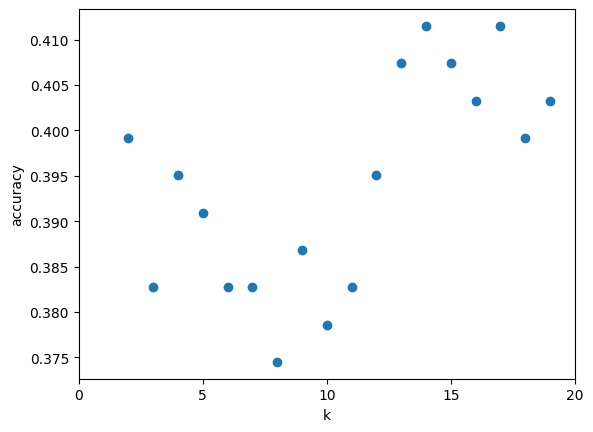

In [178]:
plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')

plt.scatter(k_range, scores)
plt.xticks([0,5,10,15,20])

In [179]:
model = KNeighborsClassifier(n_neighbors=14)

model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=14)

In [180]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

y_pred_test

array([0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0])

In [181]:
accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)

print("Accuracy Test: ", accuracy_test)
print("Accuracy Train: ", accuracy_train)

Accuracy Test:  0.411522633744856
Accuracy Train:  0.6776519052523172


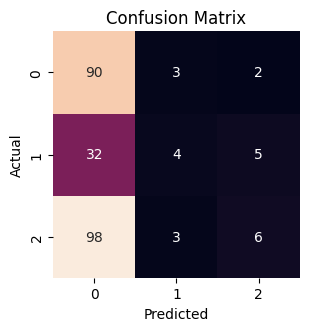

In [183]:
from sklearn.metrics import confusion_matrix

wine_cm = confusion_matrix(y_test, y_pred_test)
cm_df = pd.DataFrame(wine_cm)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()